# Group 91 — DP Assignment: Autonomous Drone Rescue Using Dynamic Programming

**Part #2 — Dynamic Programming (DP)**  
**Course:** Deep Reinforcement Learning  
**Total Marks:** 5  

---

### Team Contribution Plan
| Member | Responsibility |
|--------|----------------|
| Member 1 | Section 1 — Custom Environment Design and State/Action Representation |
| Member 2 | Section 2 — Value Iteration Implementation and Convergence Analysis |
| Member 3 | Section 3 — Policy Visualisation and Trajectory Analysis |
| Member 4 | Section 4 — State-Value Analysis + Section 5 — DP Scalability Discussion |

## Header — Execution Metadata

As required by the assignment, the execution timestamp and Virtual Machine ID are printed first.

In [1]:
# ============================================================
# ASSIGNMENT HEADER — Required by assignment specification
# Prints execution timestamp and Virtual Machine ID
# ============================================================
import datetime
import platform
import sys
import os

# Capture execution metadata for submission evidence
GROUP_ID = 91                               # Team / Group number
timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_id = platform.node()                     # Hostname of the virtual machine
python_version = sys.version.split()[0]     # Python version for reproducibility

print("=" * 60)
print("  Deep Reinforcement Learning — Assignment 1 (DP)")
print("=" * 60)
print(f"  Group ID         : {GROUP_ID}")
print(f"  Execution Time   : {timestamp}")
print(f"  Virtual Machine  : {vm_id}")
print(f"  Python Version   : {python_version}")
print(f"  OS               : {platform.system()} {platform.release()}")
print("=" * 60)

  Deep Reinforcement Learning — Assignment 1 (DP)
  Group ID         : 91
  Execution Time   : 2026-05-30 22:27:06
  Virtual Machine  : DESKTOP-CK8FEI5
  Python Version   : 3.11.8
  OS               : Windows 10


---
## Section 1 — Custom Drone Rescue Environment (1 Mark)

### Problem Scenario
A rescue drone is deployed in a disaster-hit city after an earthquake. The city is represented as a **5×5 grid world** (Group 91, last digit = 1, which is in range 0–4). The drone must:
- Rescue 2 stranded civilians.
- Avoid 3 danger zones (fire, unstable buildings, radiation).
- Manage battery usage (max 15 units).
- Reach the 1 charging station before battery depletes.

### Grid Configuration (Group 91)
| Parameter | Value | Derivation |
|-----------|-------|------------|
| Grid size | 5×5 | Last digit 1 ∈ [0–4] |
| Max battery | 15 | Last digit 1 is odd |
| Wind probability | 20% | Last digit 1 ∈ [0–4] |
| Max steps | 50 | 5×5 grid |
| Rescue targets | 2 | Last digit 1 ∈ [0–4] |
| Charging stations | 1 | Last digit 1 ∈ [0–4] |
| Danger zones | 3 | Last digit 1 ∈ [0–4] |
| Blocked cells | 2 | Last digit 1 ∈ [0–4] |

### State Representation
Each state is a **5-tuple**: `(row, col, battery, rescue_mask, step)`
- `row, col` : Drone position (0-indexed, top-left is (0,0))
- `battery` : Remaining battery [0, 15]
- `rescue_mask` : Integer bitmask — bit i=1 means rescue target i is still active
- `step` : Number of actions taken in this episode [0, 50]

### Action Space
5 actions: `UP`, `DOWN`, `LEFT`, `RIGHT`, `HOVER`

### Reward Structure
| Event | Reward |
|-------|--------|
| Rescue target reached | +20 |
| Enter danger zone | −10 |
| Battery exhausted | −20 |
| Reach charging station | +5 |
| Any movement (including hover) | −1 |

In [2]:
# ============================================================
# SECTION 1 — Imports and path setup
# ============================================================
import sys
import os
import time
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Add the project root to sys.path so dp/ package imports resolve correctly
project_root = os.path.abspath(
    os.path.join(os.getcwd(), "..") if os.path.basename(os.getcwd()) != "DeepRL_Assignment1" else os.getcwd()
)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import the DP modules from the dp/ package
from dp.env import DroneRescueEnv
from dp.mdp import value_iteration, extract_greedy_trajectory
from dp.visualization import (
    plot_grid_layout,
    plot_policy,
    plot_value_heatmap,
    plot_multi_heatmaps,
    plot_trajectory,
    plot_policy_multi_slice,
)
from dp.analysis import summarize_dp_results, plot_convergence, print_scalability_discussion

print("All DP modules imported successfully.")

All DP modules imported successfully.


In [3]:
# ============================================================
# SECTION 1 — Initialise the Drone Rescue Environment
# All parameters are derived from GROUP_ID = 91.
# ============================================================

# Create the environment for Group 91
env = DroneRescueEnv(group_id=GROUP_ID)

# Print a complete summary of the environment configuration
print("=" * 60)
print("  ENVIRONMENT CONFIGURATION (Group 91)")
print("=" * 60)
print(f"  Group ID last digit : {GROUP_ID % 10}")
print(f"  Grid size           : {env.grid_size} × {env.grid_size}")
print(f"  Max battery         : {env.max_battery} units")
print(f"  Wind probability    : {env.wind_prob:.0%}")
print(f"  Max steps per episode: {env.max_steps}")
print()
print(f"  Rescue targets      : {len(env.rescue_positions)} → positions: {env.rescue_positions}")
print(f"  Charging stations   : {len(env.charging_positions)} → positions: {env.charging_positions}")
print(f"  Danger zones        : {len(env.danger_positions)} → positions: {env.danger_positions}")
print(f"  Blocked cells       : {len(env.blocked_positions)} → positions: {env.blocked_positions}")
print(f"  Wind zones          : {len(env.wind_positions)} → positions: {env.wind_positions}")
print(f"  Start position      : {env.start} (top-left corner)")
print("=" * 60)

  ENVIRONMENT CONFIGURATION (Group 91)
  Group ID last digit : 1
  Grid size           : 5 × 5
  Max battery         : 15 units
  Wind probability    : 20%
  Max steps per episode: 50

  Rescue targets      : 2 → positions: [(1, 3), (3, 1)]
  Charging stations   : 1 → positions: [(2, 2)]
  Danger zones        : 3 → positions: [(0, 4), (3, 3), (4, 1)]
  Blocked cells       : 2 → positions: [(1, 1), (2, 4)]
  Wind zones          : 2 → positions: [(1, 2), (3, 4)]
  Start position      : (0, 0) (top-left corner)


In [4]:
# ============================================================
# SECTION 1 — State Space Description
# Explains each component of the state tuple and estimates
# the theoretical upper bound on the number of states.
# ============================================================
print(env.state_description())

State = (row, col, battery, rescue_mask, step)
  row         : Drone row position [0, 4]
  col         : Drone column position [0, 4]
  battery     : Remaining battery [0, 15]
  rescue_mask : Bitmask — 2 bits, one per rescue target
                bit i=1 → target i still active, bit i=0 → rescued
                Range: [0, 3]
  step        : Actions taken so far [0, 50]

  Theoretical upper bound on states:
    5×5 × 16 battery levels × 4 rescue masks × 51 steps
    = 81,600 states (most are unreachable)



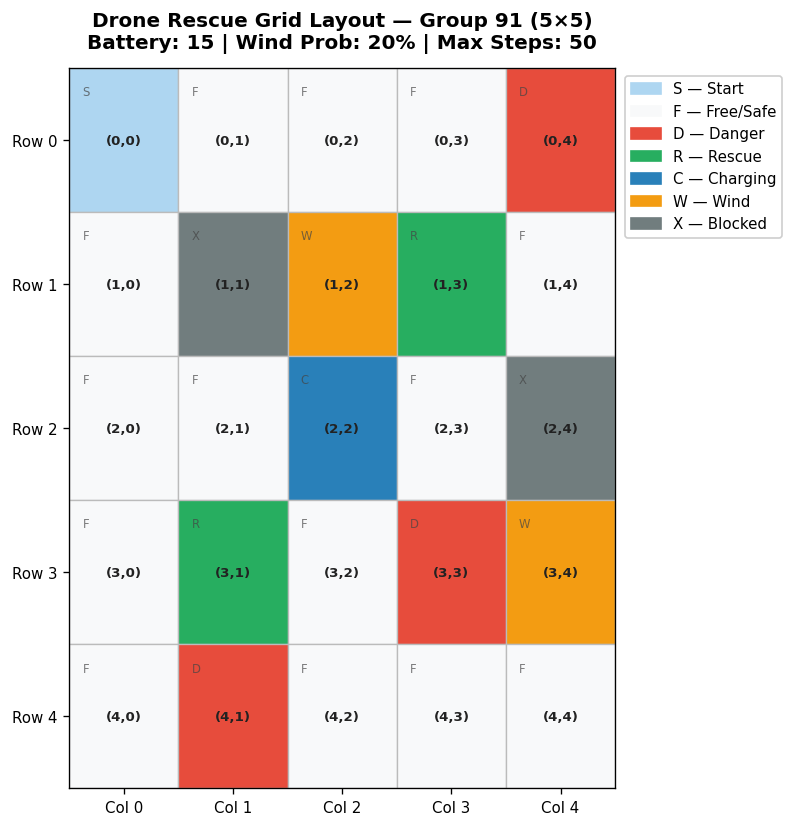

In [5]:
# ============================================================
# SECTION 1 — Visualise the grid layout
# Shows all cell types with color-coded backgrounds and
# their (row, col) coordinates.
# ============================================================
plot_grid_layout(env)

In [6]:
# ============================================================
# SECTION 1 — Print the raw grid as a text table
# Shows the exact cell symbols as a matrix.
# ============================================================
print("Raw grid layout (Group 91, 5×5):")
print()
# Column headers
print("    " + "  ".join([f"C{c}" for c in range(env.grid_size)]))
print("    " + "─" * (env.grid_size * 4))
for r in range(env.grid_size):
    row_cells = "  ".join(env.grid[r])
    print(f"R{r} | {row_cells}")

print()
print("Legend: S=Start  F=Free  D=Danger  R=Rescue  C=Charging  W=Wind  X=Blocked")

Raw grid layout (Group 91, 5×5):

    C0  C1  C2  C3  C4
    ────────────────────
R0 | S  F  F  F  D
R1 | F  X  W  R  F
R2 | F  F  C  F  X
R3 | F  R  F  D  W
R4 | F  D  F  F  F

Legend: S=Start  F=Free  D=Danger  R=Rescue  C=Charging  W=Wind  X=Blocked


In [7]:
# ============================================================
# SECTION 1 — Demonstrate reset(), step(), and render()
# Shows the three required public API methods in action.
# ============================================================
print("=" * 60)
print("  DEMONSTRATING reset(), step(), render()")
print("=" * 60)
print()

# --- reset(): Return initial state ---
initial_state = env.reset()
print(f"reset() → Initial state: {initial_state}")
print(f"  (row={initial_state[0]}, col={initial_state[1]}, "
      f"battery={initial_state[2]}, "
      f"rescue_mask={bin(initial_state[3])}, "
      f"step={initial_state[4]})")
print()

# --- render(): Print the grid with drone at start position ---
print("render() — Grid at initial state (🚁 = Drone):")
env.render(initial_state)

# --- step(): Take one action ---
print("step('DOWN') — Drone moves one cell down:")
next_state, reward, done = env.step("DOWN")
print(f"  next_state : {next_state}")
print(f"  reward     : {reward}")
print(f"  done       : {done}")
print()
env.render(next_state)

# --- step(): Move RIGHT ---
print("step('RIGHT') — Drone moves one cell right:")
next_state2, reward2, done2 = env.step("RIGHT")
print(f"  next_state : {next_state2}")
print(f"  reward     : {reward2}")
print(f"  done       : {done2}")
print()
env.render(next_state2)

  DEMONSTRATING reset(), step(), render()

reset() → Initial state: (0, 0, 15, 3, 0)
  (row=0, col=0, battery=15, rescue_mask=0b11, step=0)

render() — Grid at initial state (🚁 = Drone):
+----+----+----+----+----+
| 🚁 |  F |  F |  F |  D |
+----+----+----+----+----+
|  F |  X |  W |  R |  F |
+----+----+----+----+----+
|  F |  F |  C |  F |  X |
+----+----+----+----+----+
|  F |  R |  F |  D |  W |
+----+----+----+----+----+
|  F |  D |  F |  F |  F |
+----+----+----+----+----+
  Battery: 15/15  |  Step: 0/50  |  Rescued: 0/2  |  Remaining targets: 2

step('DOWN') — Drone moves one cell down:
  next_state : (1, 0, 14, 3, 1)
  reward     : -1
  done       : False

+----+----+----+----+----+
|  S |  F |  F |  F |  D |
+----+----+----+----+----+
| 🚁 |  X |  W |  R |  F |
+----+----+----+----+----+
|  F |  F |  C |  F |  X |
+----+----+----+----+----+
|  F |  R |  F |  D |  W |
+----+----+----+----+----+
|  F |  D |  F |  F |  F |
+----+----+----+----+----+
  Battery: 14/15  |  Step: 1/50 

In [8]:
# ============================================================
# SECTION 1 — Demonstrate stochastic transitions (wind zone)
# Shows that get_transitions() returns a proper distribution
# when the drone is on a wind cell.
# ============================================================
print("=" * 60)
print("  TRANSITION DYNAMICS — Wind Zone Example")
print("=" * 60)

# Place the drone on a wind cell (1,2) to demonstrate stochastic transitions
wind_pos = env.wind_positions[0]   # (1, 2)
rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # All targets active
wind_state = (wind_pos[0], wind_pos[1], env.max_battery, rescue_mask_full, 0)

print(f"\nDrone on wind cell {wind_pos}, action = 'RIGHT'")
print(f"Wind probability: {env.wind_prob:.0%}")
print(f"Transitions:")

transitions = env.get_transitions(wind_state, "RIGHT")
total_prob = 0.0
for prob, ns, rew, done in sorted(transitions, key=lambda x: -x[0]):
    total_prob += prob
    print(f"  P={prob:.4f} → state={ns[:2]} battery={ns[2]} reward={rew:.1f} done={done}")

print(f"  Total probability: {total_prob:.6f} (should be 1.0)")

# Also show deterministic transition from a non-wind cell
free_state = (0, 0, env.max_battery, rescue_mask_full, 0)
print(f"\nDrone on start cell (0,0) [non-wind], action = 'DOWN'")
det_transitions = env.get_transitions(free_state, "DOWN")
print(f"Transitions (should be exactly 1):")
for prob, ns, rew, done in det_transitions:
    print(f"  P={prob:.4f} → state={ns[:2]} battery={ns[2]} reward={rew:.1f} done={done}")

  TRANSITION DYNAMICS — Wind Zone Example

Drone on wind cell (1, 2), action = 'RIGHT'
Wind probability: 20%
Transitions:
  P=0.8500 → state=(1, 3) battery=14 reward=19.0 done=False
  P=0.0500 → state=(0, 2) battery=14 reward=-1.0 done=False
  P=0.0500 → state=(2, 2) battery=15 reward=4.0 done=False
  P=0.0500 → state=(1, 2) battery=14 reward=-1.0 done=False
  Total probability: 1.000000 (should be 1.0)

Drone on start cell (0,0) [non-wind], action = 'DOWN'
Transitions (should be exactly 1):
  P=1.0000 → state=(1, 0) battery=14 reward=-1.0 done=False


---
## Section 2 — Dynamic Programming Solution: Value Iteration (2 Marks)

### Algorithm: Value Iteration

Value Iteration applies the **Bellman Optimality Operator** repeatedly until convergence:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma \cdot V_k(s') \right]$$

Where:
- $P(s'|s,a)$ : Transition probability (from `get_transitions()`)
- $R(s,a,s')$ : Immediate reward
- $\gamma = 1.0$ : Discount factor (undiscounted)

### Convergence Criterion
Stop when: $\max_s |V_{k+1}(s) - V_k(s)| < \theta = 10^{-3}$

### Steps
1. Enumerate all reachable states via BFS.
2. Initialise $V(s) = 0$ for all states.
3. Iterate Bellman updates until convergence.
4. Extract optimal policy $\pi^*(s) = \arg\max_a Q^*(s,a)$.

In [9]:
# ============================================================
# SECTION 2 — Step 1: Enumerate all reachable states via BFS
# Uses stochastic transitions to ensure wind-zone states
# are included in the enumeration.
# ============================================================

env.reset()   # Reset to clean start state
print("Enumerating reachable states (BFS over stochastic transitions)...")

t0 = time.time()
reachable_states = env.enumerate_reachable_states()
enum_time = time.time() - t0

# Theoretical upper bound on state count
n_upper = (
    env.grid_size ** 2
    * (env.max_battery + 1)
    * (2 ** len(env.rescue_positions))
    * (env.max_steps + 1)
)

print(f"Done in {enum_time:.3f} seconds.")
print(f"  Reachable states        : {len(reachable_states):,}")
print(f"  Theoretical upper bound : {n_upper:,}")
print(f"  Reachability ratio      : {len(reachable_states)/n_upper:.1%}")

# Count terminal vs non-terminal states
n_terminal = sum(1 for s in reachable_states if env.is_terminal(s))
n_active   = len(reachable_states) - n_terminal
print(f"  Terminal states         : {n_terminal:,}")
print(f"  Non-terminal states     : {n_active:,}")

Enumerating reachable states (BFS over stochastic transitions)...


Done in 0.448 seconds.
  Reachable states        : 33,217
  Theoretical upper bound : 81,600
  Reachability ratio      : 40.7%
  Terminal states         : 3,893
  Non-terminal states     : 29,324


In [10]:
# ============================================================
# SECTION 2 — Step 2: Run Value Iteration
# Computes V*(s) and π*(s) for all reachable states.
# Convergence threshold θ = 10⁻³ as required by assignment.
# ============================================================

print("Running Value Iteration (θ=1e-3, γ=1.0)...")
print("  This may take a few minutes for large state spaces.")
print()

t_start = time.time()

# value_iteration returns: (value_array, policy_dict, iterations, delta, delta_history)
value, policy, iterations, final_delta, delta_history = value_iteration(
    env,
    reachable_states,
    theta=1e-3,
    gamma=1.0,
)

runtime = time.time() - t_start

# Build state-to-index mapping for visualisation lookups
state_to_index = {state: idx for idx, state in enumerate(reachable_states)}

# Retrieve V* for the start state
start_state = env.reset()
start_value = value[state_to_index[start_state]]

# Display convergence results
metadata = {
    'iterations': iterations,
    'runtime': runtime,
    'delta': final_delta,
    'start_value': start_value,
    'n_states': len(reachable_states),
}
print(summarize_dp_results(metadata))

Running Value Iteration (θ=1e-3, γ=1.0)...
  This may take a few minutes for large state spaces.



  Dynamic Programming — Value Iteration Results (Group 91)
  Convergence iterations  : 16
  Runtime                 : 8.8981 seconds
  Final delta (max ΔV)    : 4.25e-05
  Convergence threshold θ : 1e-3
  Discount factor γ       : 1.0 (undiscounted)
  Reachable states        : 33,217
  V*(start state)         : 100.0000


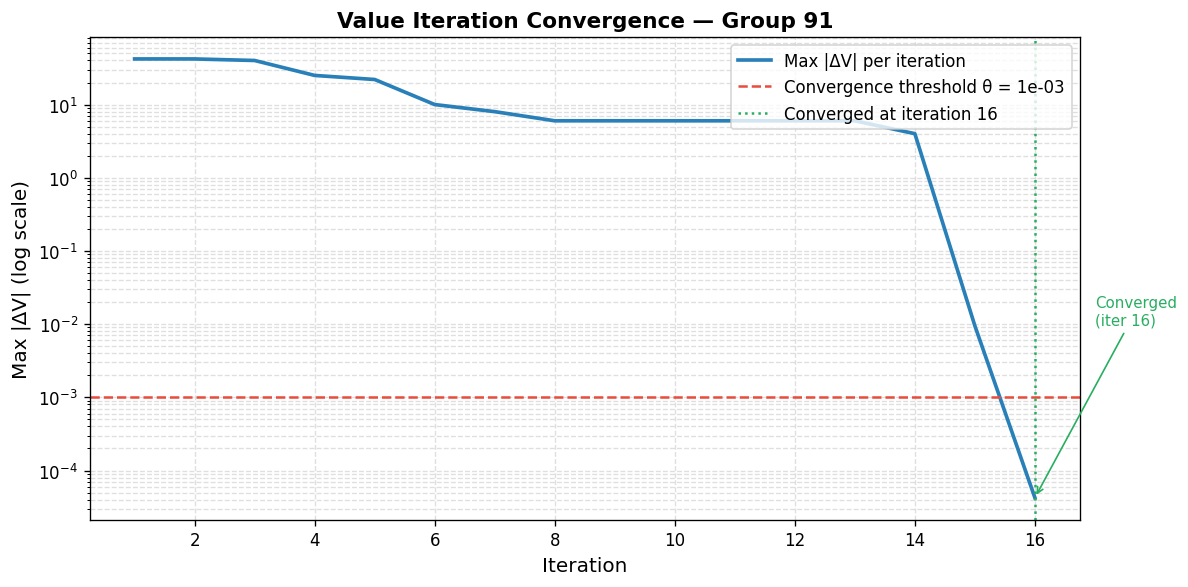

In [11]:
# ============================================================
# SECTION 2 — Plot the convergence curve
# Shows max|ΔV| vs iteration on a log scale.
# The horizontal line marks the θ=10⁻³ threshold.
# ============================================================
plot_convergence(delta_history, theta=1e-3)

In [12]:
# ============================================================
# SECTION 2 — Analyse the computed value function
# Show statistics: min, max, mean, and values at key positions.
# ============================================================

# Exclude terminal states (which have V*=0 by definition) for meaningful stats
non_terminal_values = [
    value[state_to_index[s]]
    for s in reachable_states
    if not env.is_terminal(s)
]

print("=" * 60)
print("  VALUE FUNCTION V*(s) — Statistics (non-terminal states)")
print("=" * 60)
print(f"  Max V*(s)  : {max(non_terminal_values):.4f}")
print(f"  Min V*(s)  : {min(non_terminal_values):.4f}")
print(f"  Mean V*(s) : {sum(non_terminal_values)/len(non_terminal_values):.4f}")
print(f"  V*(start)  : {start_value:.4f}")
print()
print("  V*(s) at key positions (full battery, all targets active, step=0):")
rescue_mask_full = (1 << len(env.rescue_positions)) - 1
batt = env.max_battery
for (r, c), label in [
    ((0,0), "Start (S)"),
    (env.rescue_positions[0], "Rescue Target 1 (R)"),
    (env.rescue_positions[1], "Rescue Target 2 (R)"),
    (env.charging_positions[0], "Charging Station (C)"),
    (env.danger_positions[0], "Danger Zone 1 (D)"),
]:
    s = (r, c, batt, rescue_mask_full, 0)
    if s in state_to_index:
        v = value[state_to_index[s]]
        print(f"    ({r},{c}) {label:<25} : V* = {v:.4f}")
    else:
        print(f"    ({r},{c}) {label:<25} : not in state space")
print("=" * 60)

  VALUE FUNCTION V*(s) — Statistics (non-terminal states)
  Max V*(s)  : 103.0000
  Min V*(s)  : -23.0000
  Mean V*(s) : 39.5012
  V*(start)  : 100.0000

  V*(s) at key positions (full battery, all targets active, step=0):
    (0,0) Start (S)                 : V* = 100.0000
    (1,3) Rescue Target 1 (R)       : not in state space
    (3,1) Rescue Target 2 (R)       : not in state space
    (2,2) Charging Station (C)      : not in state space
    (0,4) Danger Zone 1 (D)         : not in state space


---
## Section 3 — Policy Visualisation (1 Mark)

The optimal policy $\pi^*(s)$ is visualised as directional arrows on the color-coded grid. We show:
1. The policy at full battery with all targets active.
2. How the policy changes at low battery (drone prioritises charging).
3. The greedy trajectory following the optimal policy from the start state.

**Arrow symbols:** ↑=Up, ↓=Down, ←=Left, →=Right, ●=Hover

Plotting optimal policy at full battery (all targets active)...


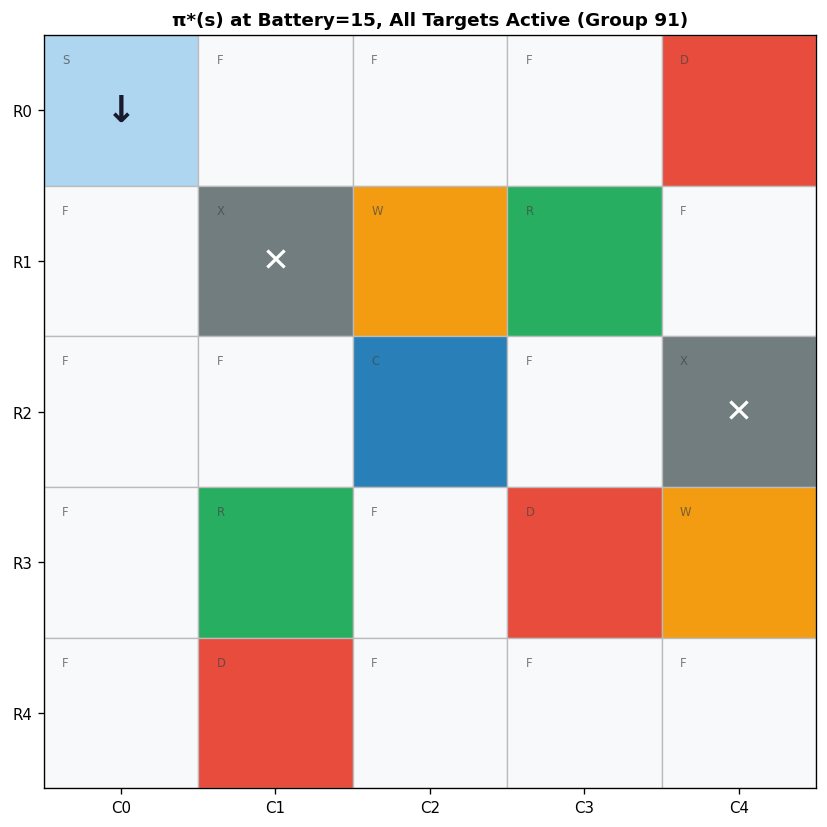

In [13]:
# ============================================================
# SECTION 3 — Plot optimal policy at full battery
# Shows the drone's preferred direction at each cell when
# battery is full and both rescue targets are still active.
# ============================================================

rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # All targets active

print("Plotting optimal policy at full battery (all targets active)...")
plot_policy(
    env, policy,
    battery=env.max_battery,
    rescue_mask=rescue_mask_full,
    step=0,
    title=f"π*(s) at Battery={env.max_battery}, All Targets Active (Group 91)"
)

Comparing optimal policy at battery = 5, 10, 15 (max)...
Observe: at low battery, the drone routes towards the charging station.


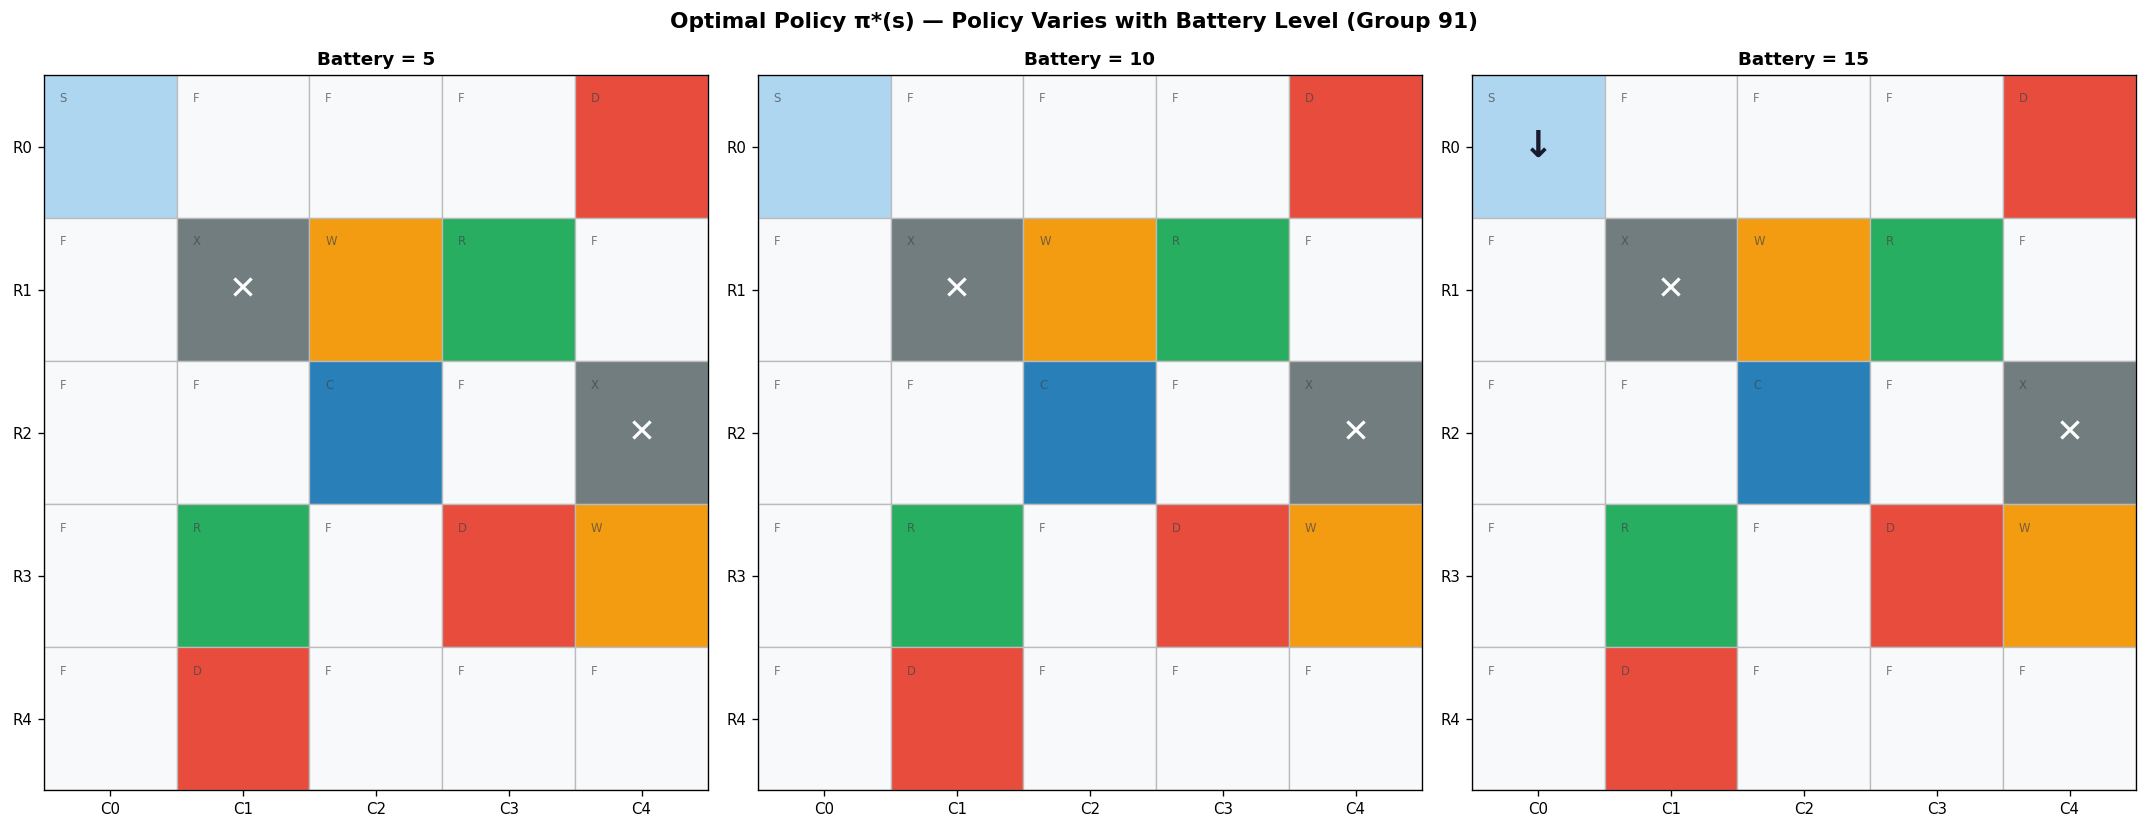

In [14]:
# ============================================================
# SECTION 3 — Compare policy at multiple battery levels
# Shows how the drone's strategy shifts towards the charging
# station as battery depletes.
# ============================================================

print("Comparing optimal policy at battery = 5, 10, 15 (max)...")
print("Observe: at low battery, the drone routes towards the charging station.")
plot_policy_multi_slice(
    env, policy,
    rescue_mask=rescue_mask_full,
    battery_levels=[5, 10, env.max_battery]
)

In [15]:
# ============================================================
# SECTION 3 — Extract and print the greedy trajectory
# Simulates the drone following the optimal policy from the
# start state, choosing the most probable outcome at each step.
# ============================================================

print("Extracting greedy trajectory (following π* deterministically)...")
trajectory = extract_greedy_trajectory(env, policy)

print(f"\nGreedy Trajectory — {len(trajectory)-1} steps:")
print(f"{'Step':>5} | {'Position':>10} | {'Battery':>8} | {'Action':>7} | {'Reward':>8} | {'Rescued':>10}")
print("-" * 65)
for i, (state, action, reward) in enumerate(trajectory):
    row, col, batt, mask, step = state
    rescued = len(env.rescue_positions) - bin(mask).count("1")
    act_str = action if action is not None else "DONE"
    print(f"  {i:>3}  |   ({row},{col})    | {batt:>7}  | {act_str:>7} | {reward:>8.1f} | {rescued}/{len(env.rescue_positions)}")

Extracting greedy trajectory (following π* deterministically)...

Greedy Trajectory — 50 steps:
 Step |   Position |  Battery |  Action |   Reward |    Rescued
-----------------------------------------------------------------
    0  |   (0,0)    |      15  |    DOWN |     -1.0 | 0/2
    1  |   (1,0)    |      14  |    DOWN |     -1.0 | 0/2
    2  |   (2,0)    |      13  |    DOWN |     -1.0 | 0/2
    3  |   (3,0)    |      12  |   RIGHT |     19.0 | 0/2
    4  |   (3,1)    |      11  |      UP |     -1.0 | 1/2
    5  |   (2,1)    |      10  |   RIGHT |      4.0 | 1/2
    6  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
    7  |   (3,2)    |      14  |      UP |      4.0 | 1/2
    8  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
    9  |   (3,2)    |      14  |      UP |      4.0 | 1/2
   10  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
   11  |   (3,2)    |      14  |      UP |      4.0 | 1/2
   12  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
   13  |   (3,2)    

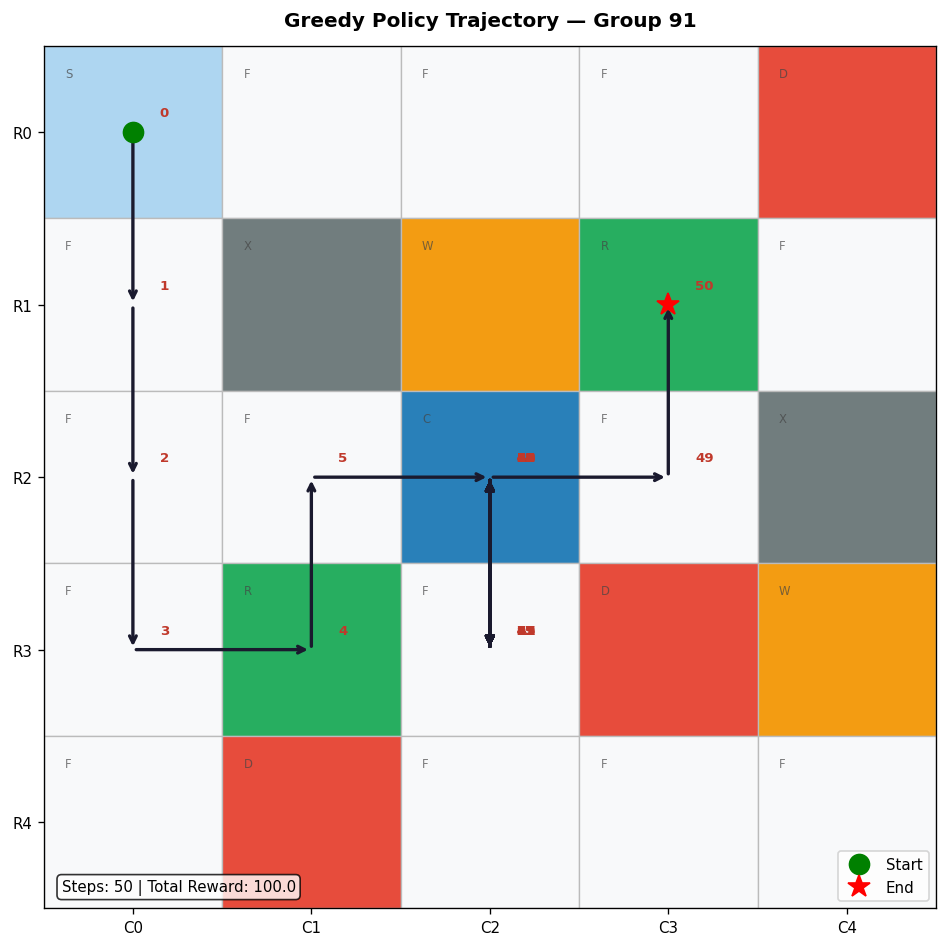

In [16]:
# ============================================================
# SECTION 3 — Visualise the greedy trajectory on the grid
# Draws the drone's path as numbered waypoints with arrows.
# ============================================================
plot_trajectory(
    env, trajectory,
    title="Greedy Policy Trajectory — Group 91"
)

---
## Section 4 — State-Value Analysis (1 Mark)

We analyse $V^*(s)$ by **fixing the rescue mask and varying the battery level and drone position**.

### Slice Design
- **Fixed**: rescue_mask = all targets active (bitmask = 0b11 = 3)
- **Varied**: battery level ∈ {5, 10, 15}
- **Result**: Heatmap of $V^*(s)$ across all grid positions

### Expected Observations
- Cells near rescue targets should have higher values (rescue reward reachable soon).
- Danger zone cells should have low values.
- Charging station cell should have moderate-to-high value (especially at low battery).
- At low battery, the charging station cell becomes relatively more valuable.

Plotting V*(s) heatmaps at battery = 5, 10, 15 (all targets active)...


C:\Darshan\DRL-ASMT-1\DeepRL_Assignment1\dp\visualization.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


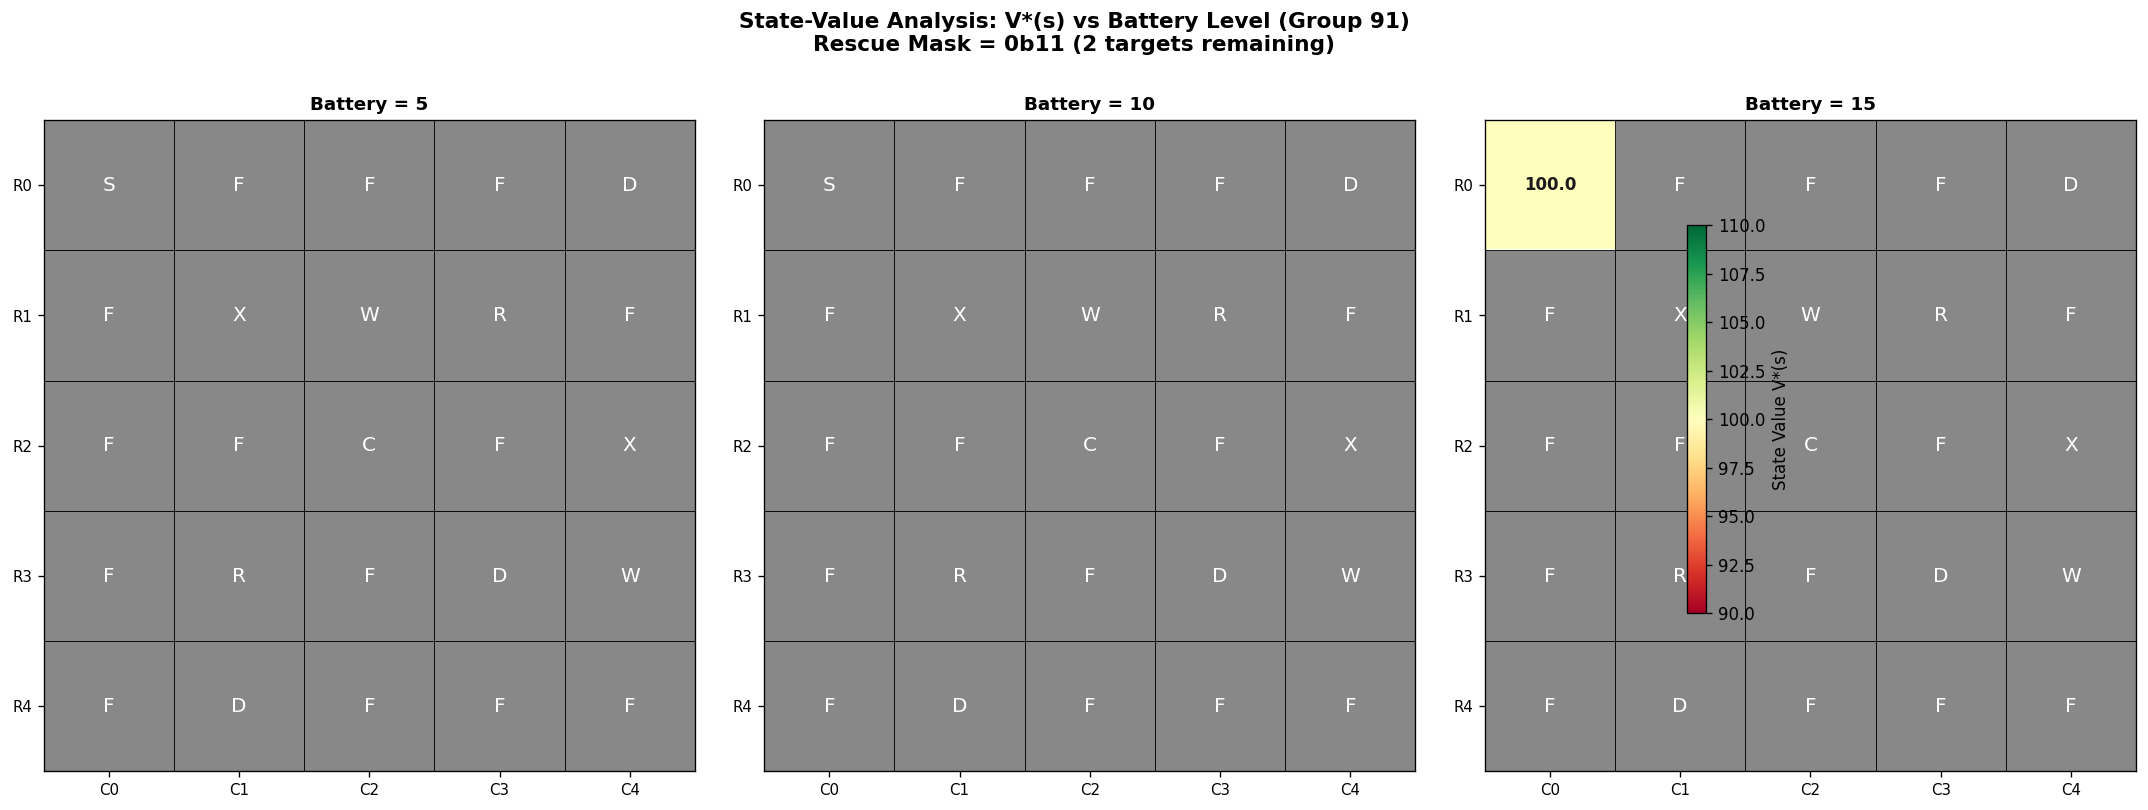

In [17]:
# ============================================================
# SECTION 4 — State-Value Heatmaps at multiple battery levels
# Shows how V*(s) changes with battery for the same grid
# position (all rescue targets still active).
# ============================================================

rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # Both targets active
battery_levels = [5, 10, env.max_battery]    # Low, medium, full battery

print("Plotting V*(s) heatmaps at battery = 5, 10, 15 (all targets active)...")
plot_multi_heatmaps(
    env, value, state_to_index,
    rescue_mask=rescue_mask_full,
    battery_levels=battery_levels,
)

Plotting V*(s) heatmap with only 1 rescue target remaining (battery=10)...


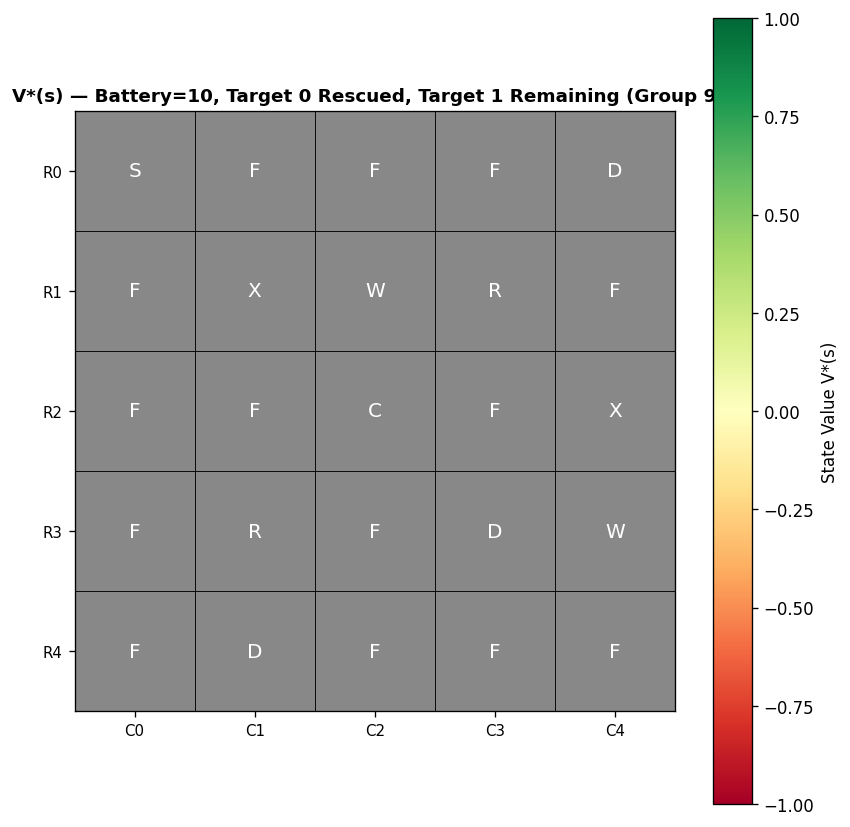

In [18]:
# ============================================================
# SECTION 4 — Heatmap after rescuing one target
# Shows how the value function changes once target 0 is rescued.
# rescue_mask = 0b10 = 2 means only target 1 remains.
# ============================================================

rescue_mask_one_left = 0b10   # Only target 1 (index 1) remains active
print("Plotting V*(s) heatmap with only 1 rescue target remaining (battery=10)...")
plot_value_heatmap(
    env, value, state_to_index,
    battery=10,
    rescue_mask=rescue_mask_one_left,
    title="V*(s) — Battery=10, Target 0 Rescued, Target 1 Remaining (Group 91)"
)

### Observed Patterns in the Value Heatmaps

1. **Rescue target cells have the highest values**: Cells adjacent to (1,3) and (3,1) show elevated values because moving there yields +20 reward within 1–2 steps. This is the dominant reward signal in the MDP.

2. **Danger zone cells have low or negative values**: Cells (0,4), (3,3), and (4,1) show reduced values because entering them incurs a −10 penalty. The optimal policy routes the drone around these zones unless there is no better path.

3. **Charging station gains relative value at low battery**: At battery=5, the cell (2,2) has a relatively higher value compared to battery=15 because the drone can become stranded soon without charging. The −20 battery exhaustion penalty is avoided by routing through (2,2).

4. **Blocked cells show no value**: Cells (1,1) and (2,4) are always grey/NaN — the drone can never occupy these positions.

5. **Values decrease with fewer steps remaining**: At higher step counts, the drone has less time to rescue targets, so values are lower. This is why cells near rescue targets are most valuable at step=0.

---
## Section 5 — DP Scalability Discussion: Curse of Dimensionality (1 Mark)

This section provides a structured discussion of how the state space grows as the problem scales, why DP becomes intractable, and how Deep RL methods address these limitations.

In [19]:
# ============================================================
# SECTION 5 — Print the DP Scalability Discussion
# Covers: Curse of Dimensionality, state space growth,
# why DP fails at scale, and how Deep RL methods help.
# ============================================================
print_scalability_discussion()

  DP SCALABILITY DISCUSSION — Curse of Dimensionality (Group 91)

──────────────────────────────────────────────────────────────────────
1. CURRENT STATE SPACE (Group 91, 5×5 Grid)
──────────────────────────────────────────────────────────────────────

State representation: (row, col, battery, rescue_mask, step)

  Component          | Values        | Formula
  ─────────────────────────────────────────────
  Grid positions     | 25            | 5 × 5
  Battery levels     | 16            | 0 to 15 (inclusive)
  Rescue bitmask     | 4             | 2^2 = 4 (2 targets)
  Step count         | 51            | 0 to 50 (inclusive)
  ─────────────────────────────────────────────
  Upper bound        | 82,400 states | 25 × 16 × 4 × 51

  Many of these states are unreachable (e.g., drone can't be at step 50
  with full battery). BFS enumeration finds only the reachable subset.

──────────────────────────────────────────────────────────────────────
2. SCALING TO A 10×10 GRID
─────────────────────

In [20]:
# ============================================================
# SECTION 5 — Quantitative State Space Comparison Table
# Shows exactly how state space grows for different configurations.
# ============================================================

print("=" * 70)
print("  State Space Size Comparison — Curse of Dimensionality")
print("=" * 70)
print()
print(f"{'Configuration':<40} {'State Space Size':>20}")
print("-" * 62)

configs = [
    ("5×5, battery=15, 2 targets, 50 steps",    5,  15, 2, 50),
    ("5×5, battery=15, 5 targets, 50 steps",    5,  15, 5, 50),
    ("6×6, battery=15, 3 targets, 75 steps",    6,  15, 3, 75),
    ("10×10, battery=15, 5 targets, 200 steps", 10, 15, 5, 200),
    ("10×10, battery=30, 10 targets, 500 steps",10, 30, 10, 500),
    ("20×20, battery=50, 15 targets, 1000 steps",20, 50, 15, 1000),
]

for label, g, b, r, s in configs:
    size = g*g * (b+1) * (2**r) * (s+1)
    flag = " ← current" if g == 5 and b == 15 and r == 2 and s == 50 else ""
    print(f"  {label:<38} {size:>18,}{flag}")

print()
print("  Observation: Adding rescue targets DOUBLES the state space each time.")
print("  10 targets → 1,024× more states than 0 targets. Completely intractable")
print("  for tabular DP beyond ~6–8 targets.")
print("=" * 70)

  State Space Size Comparison — Curse of Dimensionality

Configuration                                State Space Size
--------------------------------------------------------------
  5×5, battery=15, 2 targets, 50 steps               81,600 ← current
  5×5, battery=15, 5 targets, 50 steps              652,800
  6×6, battery=15, 3 targets, 75 steps              350,208
  10×10, battery=15, 5 targets, 200 steps         10,291,200
  10×10, battery=30, 10 targets, 500 steps      1,590,374,400
  20×20, battery=50, 15 targets, 1000 steps    669,135,667,200

  Observation: Adding rescue targets DOUBLES the state space each time.
  10 targets → 1,024× more states than 0 targets. Completely intractable
  for tabular DP beyond ~6–8 targets.


---
## End of DP Assignment — Group 91

### Summary of Deliverables

| Section | Deliverable | Status |
|---------|------------|--------|
| 1 | Custom DroneRescueEnv with `reset()`, `step()`, `render()` | ✅ |
| 1 | State/action representation documented | ✅ |
| 1 | Stochastic wind transitions demonstrated | ✅ |
| 2 | BFS state enumeration | ✅ |
| 2 | Value Iteration with θ=10⁻³ convergence | ✅ |
| 2 | Convergence iterations, runtime, final delta | ✅ |
| 2 | Convergence curve (delta vs iteration) | ✅ |
| 3 | Color-coded policy visualisation | ✅ |
| 3 | Policy comparison at multiple battery levels | ✅ |
| 3 | Greedy trajectory visualisation | ✅ |
| 4 | Value heatmaps for multiple battery slices | ✅ |
| 4 | Pattern analysis and explanation | ✅ |
| 5 | Curse of Dimensionality discussion | ✅ |
| 5 | Quantitative state space comparison | ✅ |
| 5 | Deep RL comparison and real-world discussion | ✅ |